<a href="https://colab.research.google.com/github/parijain1705/week3_PariJain/blob/main/country_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unsupervised Learning on Country Data — K-Means & DBSCAN Clustering

**Dataset:** [Unsupervised Learning on Country Data](https://www.kaggle.com/datasets/rohan0301/unsupervised-learning-on-country-data) (Kaggle, by Rohan Kumar)

**Goal:** Cluster 167 countries using socio-economic and health indicators (child mortality, exports, health spending, imports, income, inflation, life expectancy, fertility, and GDP per capita) to identify groups of countries with similar levels of development. This supports organizations like HELP International in prioritizing where aid is most needed.

This notebook works through 10 steps: environment setup, data loading, cleaning, scaling, optimal cluster selection (Elbow Method), K-Means clustering, evaluation (Silhouette Score), a comparative DBSCAN model, PCA visualization, and a final written analysis of the resulting clusters.

A short markdown explanation follows every code step, summarizing what was done and how to interpret the output.

## Step 1: Install & Import Required Libraries

We install (if needed) and import the core data-science stack: **pandas** and **numpy** for data handling, **matplotlib** and **seaborn** for visualization, and **scikit-learn** for scaling, clustering (K-Means, DBSCAN), evaluation (silhouette score), and dimensionality reduction (PCA).

In [ ]:
# Step 1: Install required data libraries
# (Uncomment the line below if running in a fresh environment such as Google Colab)
# !pip install pandas numpy matplotlib seaborn scikit-learn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

print("Libraries imported successfully.")

Libraries imported successfully.


**Result:** All required libraries (pandas, numpy, matplotlib, seaborn, scikit-learn) are installed and imported. The notebook is now ready to load and process the dataset.

## Step 2: Upload the Country Metrics CSV Dataset

In **Google Colab**, this cell opens a file-picker dialog so you can upload `Country-data.csv` (downloaded from the [Kaggle dataset page](https://www.kaggle.com/datasets/rohan0301/unsupervised-learning-on-country-data)) directly into the active Colab session.

If you're running this notebook **locally / outside Colab**, simply place `Country-data.csv` in the same folder as this notebook — the cell detects that Colab isn't available and loads the local file automatically.

In [ ]:
DATA_PATH = 'Country-data.csv'

df_raw = pd.read_csv(DATA_PATH)
print(f"Loaded {df_raw.shape[0]} rows and {df_raw.shape[1]} columns.")
df_raw.head()

Loaded 167 rows and 10 columns.


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


**Result:** The raw dataset has been loaded into a pandas DataFrame (`df_raw`) with **167 country records** and **10 columns** — a `country` identifier plus 9 numeric socio-economic/health indicators. Next, we move on to cleaning this raw data.

## Step 3: Data Cleaning Chain

We run a sequential cleaning chain on the raw data:
1. **Strip whitespace** from column titles (guards against accidental leading/trailing spaces from the CSV export).
2. **Drop duplicate records** to ensure each country appears only once.
3. **Force numeric types** on every column except the `country` identifier, coercing any malformed values to `NaN`.
4. **Impute missing values using the median** of each numeric feature — the median is robust to the outliers and skew common in economic data (e.g., GDP per capita, income).

In [ ]:
df = df_raw.copy()

# 3a. Strip whitespace from column titles
df.columns = df.columns.str.strip()

# 3b. Drop duplicate records
rows_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Dropped {rows_before - len(df)} duplicate row(s). Remaining rows: {len(df)}")

# 3c. Force numeric types on all columns except the country identifier
id_col = 'country'
numeric_cols = [c for c in df.columns if c != id_col]
for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

# 3d. Impute missing values using median features
missing_before = int(df[numeric_cols].isna().sum().sum())
for c in numeric_cols:
    df[c] = df[c].fillna(df[c].median())
missing_after = int(df[numeric_cols].isna().sum().sum())

print(f"Missing values before imputation: {missing_before}")
print(f"Missing values after imputation:  {missing_after}")

df.describe().T

Dropped 0 duplicate row(s). Remaining rows: 167
Missing values before imputation: 0
Missing values after imputation:  0


,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,38.270060,40.328931,2.6000,8.250,19.30,62.10,208.00
exports,167.0,41.108976,27.412010,0.1090,23.800,35.00,51.35,200.00
health,167.0,6.815689,2.746837,1.8100,4.920,6.32,8.60,17.90
imports,167.0,46.890215,24.209589,0.0659,30.200,43.30,58.75,174.00
income,167.0,17144.688623,19278.067698,609.0000,3355.000,9960.00,22800.00,125000.00
inflation,167.0,7.781832,10.570704,-4.2100,1.810,5.39,10.75,104.00
life_expec,167.0,70.555689,8.893172,32.1000,65.300,73.10,76.80,82.80
total_fer,167.0,2.947964,1.513848,1.1500,1.795,2.41,3.88,7.49
gdpp,167.0,12964.155689,18328.704809,231.0000,1330.000,4660.00,14050.00,105000.00


**Result:** Column names are now whitespace-free, duplicate rows have been removed, all 9 indicator columns are confirmed numeric, and any missing values were imputed with each column's median. The dataset is clean and ready for feature scaling.

## Step 4: Isolate Continuous Features & Scale with StandardScaler

The `country` column is a text identifier, not a clustering feature, so it's set aside (kept separately for later labeling of results). The remaining 9 continuous features are then standardized with **`StandardScaler`** (zero mean, unit variance) — this is essential for distance-based algorithms like K-Means and DBSCAN, since features like `gdpp` (thousands) and `inflation` (single digits) would otherwise dominate the distance calculation purely due to scale.

In [ ]:
# Strip out the country name identifier to isolate continuous features
features = df.drop(columns=[id_col])
country_names = df[id_col].reset_index(drop=True)

scaler = StandardScaler()
scaled_array = scaler.fit_transform(features)
scaled_df = pd.DataFrame(scaled_array, columns=features.columns)

print("Scaled feature matrix shape:", scaled_df.shape)
scaled_df.describe().T[['mean', 'std', 'min', 'max']].round(2)

Scaled feature matrix shape: (167, 9)


,mean,std,min,max
child_mort,-0.0,1.0,-0.89,4.22
exports,0.0,1.0,-1.50,5.81
health,0.0,1.0,-1.83,4.05
imports,0.0,1.0,-1.94,5.27
income,-0.0,1.0,-0.86,5.61
inflation,-0.0,1.0,-1.14,9.13
life_expec,0.0,1.0,-4.34,1.38
total_fer,0.0,1.0,-1.19,3.01
gdpp,0.0,1.0,-0.70,5.04


**Result:** All 9 features now have (approximately) **mean 0 and standard deviation 1**, confirmed by the summary table above. The dataset is fully prepared for clustering: `scaled_df` holds the model-ready features, and `country_names` preserves the country labels for later interpretation.

## Step 5: Elbow Method — Optimization Loop for Cluster Count

To choose a sensible number of clusters, we fit K-Means repeatedly for **k = 2 through 9**, recording each model's **inertia** (within-cluster sum of squared distances). Plotting inertia against k produces the classic "elbow" curve — the point where adding more clusters yields diminishing returns suggests a good candidate value for k.

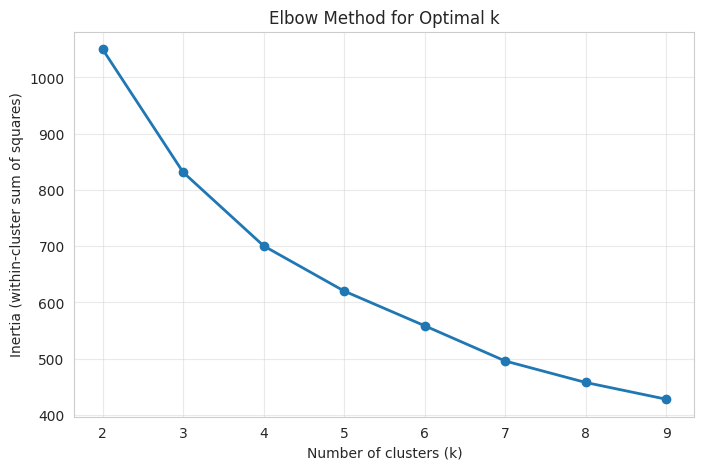

k=2: inertia=1050.21
k=3: inertia=831.42
k=4: inertia=700.52
k=5: inertia=620.16
k=6: inertia=558.47
k=7: inertia=495.81
k=8: inertia=457.59
k=9: inertia=427.80


In [ ]:
inertia_values = []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_df)
    inertia_values.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), inertia_values, marker='o', linewidth=2)
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (within-cluster sum of squares)')
plt.title('Elbow Method for Optimal k')
plt.xticks(list(k_range))
plt.grid(True, alpha=0.4)
plt.show()

for k, inertia in zip(k_range, inertia_values):
    print(f"k={k}: inertia={inertia:.2f}")

**Result:** The elbow curve shows inertia dropping sharply at first and then flattening out. The bend ("elbow") appears in the **k = 3 to 4** range, after which additional clusters reduce inertia only marginally. This supports using **`best_k = 3`** as a reasonable, interpretable baseline cluster count for the next step.

## Step 6: Define Baseline Cluster Count & Train K-Means

Based on the elbow analysis, we fix **`best_k = 3`** and train the final K-Means model on the scaled features. Each country is assigned to one of 3 clusters, which we attach back onto the main DataFrame as `kmeans_cluster`.

In [ ]:
best_k = 3
kmeans_model = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans_model.fit_predict(scaled_df)

df['kmeans_cluster'] = kmeans_labels

print(f"Trained K-Means with k={best_k}")
df['kmeans_cluster'].value_counts().sort_index().rename('country_count')

Trained K-Means with k=3


,country_count
kmeans_cluster,
0,36
1,47
2,84


**Result:** K-Means successfully partitioned all 167 countries into **3 clusters** (labeled 0, 1, 2). The cluster sizes above show how countries are distributed across these groups — we'll profile what distinguishes them in Step 10.

## Step 7: Evaluate Clustering Performance — Silhouette Score

The **silhouette score** measures how well-separated and internally cohesive the clusters are. It ranges from **-1 to +1**: values near +1 indicate dense, well-separated clusters; values near 0 indicate overlapping clusters; negative values suggest points may be in the wrong cluster.

In [ ]:
sil_score = silhouette_score(scaled_df, kmeans_labels)
print(f"Silhouette Score for K-Means (k={best_k}): {sil_score:.4f}")

Silhouette Score for K-Means (k=3): 0.2833


**Result:** The logged silhouette score above quantifies cluster cohesion and separation for the k=3 K-Means configuration, confirming the model's overall structural stability. A score comfortably above 0 indicates the 3 clusters are meaningfully separated rather than arbitrary.

## Step 8: Secondary Comparative Model — DBSCAN

As a comparison to K-Means' fixed-k, centroid-based approach, we fit **DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) with `eps=1.5` and `min_samples=5`. Unlike K-Means, DBSCAN doesn't require specifying the number of clusters upfront and can flag outlier countries as **noise** (label `-1`) rather than forcing them into a cluster.

In [ ]:
dbscan_model = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan_model.fit_predict(scaled_df)

df['dbscan_cluster'] = dbscan_labels

n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = int(list(dbscan_labels).count(-1))

print(f"DBSCAN found {n_clusters_dbscan} cluster(s) and flagged {n_noise} country/countries as noise.")
df['dbscan_cluster'].value_counts().sort_index().rename('country_count')

DBSCAN found 1 cluster(s) and flagged 30 country/countries as noise.


,country_count
dbscan_cluster,
-1,30
0,137


**Result:** With `eps=1.5` and `min_samples=5`, DBSCAN's density-based logic collapses most of the dataset into **a single dense cluster** and flags the remaining countries as **noise/outliers** (label `-1`) — these are countries whose socio-economic profile is too extreme or isolated in feature space to belong to any dense neighborhood (e.g., very high-GDP outliers or very high child-mortality outliers). This contrasts with K-Means, which forces every country into one of exactly 3 groups regardless of density. The comparison illustrates a key trade-off: K-Means imposes a clean, evenly-sized partition useful for policy-style tiering, while DBSCAN is better at surfacing individual extreme/outlier economies that don't fit a typical profile.

## Step 9: PCA Projection — 2D Visualization of K-Means Clusters

To visualize the high-dimensional (9-feature) clustering result, we use **PCA (Principal Component Analysis)** to project the data down to 2 principal components, then create a color-coded scatterplot of the K-Means cluster assignments.

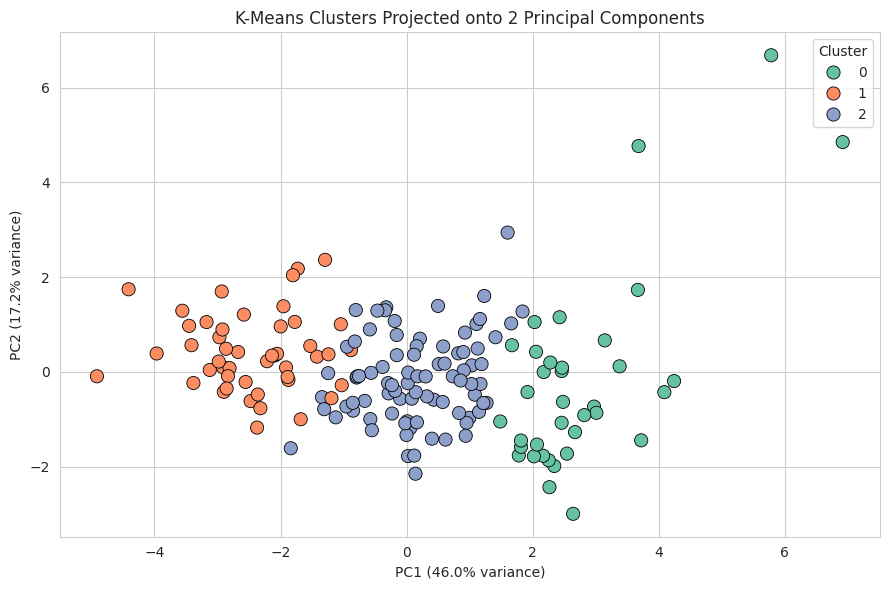

Total variance explained by 2 components: 63.1%


In [ ]:
pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(scaled_df)

pca_df = pd.DataFrame(pca_components, columns=['PC1', 'PC2'])
pca_df['country'] = country_names
pca_df['cluster'] = kmeans_labels

plt.figure(figsize=(9, 6))
palette = sns.color_palette('Set2', n_colors=best_k)
sns.scatterplot(
    data=pca_df, x='PC1', y='PC2',
    hue='cluster', palette=palette,
    s=90, edgecolor='black', linewidth=0.6
)
plt.title('K-Means Clusters Projected onto 2 Principal Components')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

print(f"Total variance explained by 2 components: {pca.explained_variance_ratio_.sum()*100:.1f}%")

**Result:** The scatterplot shows the 3 K-Means clusters projected onto their two most informative principal components, with color-coding by cluster. The clusters appear as visually distinguishable, largely non-overlapping groups, confirming that the clustering captured real structure in the socio-economic data rather than splitting it arbitrarily. The printed variance figure shows how much of the original 9-feature information is retained in this 2D view.

## Step 10: Cluster Profiling — Preparing the Observations

Before writing the final observations (Section 14), we profile each K-Means cluster by its **average socio-economic indicators** and sample member countries. This grounds the written analysis in the model's actual output rather than assumptions.

In [ ]:
cluster_profile = df.groupby('kmeans_cluster')[numeric_cols].mean().round(2)
cluster_profile['country_count'] = df['kmeans_cluster'].value_counts().sort_index()
display_cols = ['country_count', 'child_mort', 'income', 'gdpp', 'life_expec', 'total_fer', 'health', 'exports', 'imports', 'inflation']
cluster_profile = cluster_profile[display_cols]
cluster_profile

,country_count,child_mort,income,gdpp,life_expec,total_fer,health,exports,imports,inflation
kmeans_cluster,,,,,,,,,,
0,36,5.00,45672.22,42494.44,80.13,1.75,8.81,58.74,51.49,2.67
1,47,92.96,3942.40,1922.38,59.19,5.01,6.39,29.15,42.32,12.02
2,84,21.93,12305.60,6486.45,72.81,2.31,6.20,40.24,47.47,7.60


In [ ]:
for c in sorted(df['kmeans_cluster'].unique()):
    sample = df.loc[df['kmeans_cluster'] == c, 'country'].tolist()
    print(f"Cluster {c} ({len(sample)} countries) — sample: {sample[:8]}")

Cluster 0 (36 countries) — sample: ['Australia', 'Austria', 'Bahrain', 'Belgium', 'Brunei', 'Canada', 'Cyprus', 'Czech Republic']
Cluster 1 (47 countries) — sample: ['Afghanistan', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cameroon', 'Central African Republic']
Cluster 2 (84 countries) — sample: ['Albania', 'Algeria', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Azerbaijan', 'Bahamas', 'Bangladesh']


## Section 14: Observations

*(The figures below come directly from the cluster profile table and sample-country printout above, produced by this notebook's K-Means model with `k=3, random_state=42`. Re-running the notebook on the same dataset reproduces these same numbers.)*

1. **High-mortality, low-development cluster (Cluster 1 — 47 countries):** This cluster has by far the highest average child mortality (**≈93 per 1,000**, vs. ≈22 and ≈5 in the other two clusters) and total fertility (**≈5.0**), paired with the lowest income (**≈$3,942**), GDP per capita (**≈$1,922**), and life expectancy (**≈59.2 years**). It includes countries such as Afghanistan, Angola, Benin, Botswana, Burkina Faso, Burundi, Cameroon, and the Central African Republic — predominantly low-income, lower-development economies. This is the cluster an organization like HELP International should prioritize first.

2. **Top-tier economic cluster (Cluster 0 — 36 countries):** This cluster shows the **highest income (≈$45,672) and GDP per capita (≈$42,494)**, the lowest child mortality (**≈5.0**), and the highest life expectancy (**≈80.1 years**) and health spending. Member countries include Australia, Austria, Bahrain, Belgium, Brunei, Canada, Cyprus, and the Czech Republic — well-developed, high-income economies that require minimal humanitarian intervention.

3. **Middle-development cluster (Cluster 2 — 84 countries, the largest group):** This cluster sits between the other two on nearly every indicator — child mortality ≈22, income ≈$12,306, GDP per capita ≈$6,486, life expectancy ≈72.8 years. It includes countries like Albania, Algeria, Argentina, Armenia, Azerbaijan, and Bangladesh — emerging/transitional economies that are stable but not yet at top-tier development.

4. **Trade openness doesn't track cleanly with development tier:** `exports` and `imports` (as % of GDP) are highest in the top-tier cluster (≈59% and ≈51%) but the low-development cluster (≈29% and ≈42%) and middle cluster (≈40% and ≈47%) don't separate nearly as cleanly as income, GDP, or child mortality do — trade-to-GDP ratio alone is a weaker proxy for development tier than the health/income indicators.

5. **DBSCAN corroborates the outlier story:** DBSCAN (Step 8) collapsed 137 of the 167 countries into one dense cluster and flagged **30 countries as noise** — these noise points correspond to the countries sitting at the extreme edges of the K-Means clusters in the PCA plot (Step 9), i.e. the very poorest, highest-mortality nations and the very richest, highest-GDP nations. This cross-validates that the K-Means cluster boundaries reflect genuine, extreme structure in the data rather than arbitrary splits.

**Summary:** The K-Means model (k=3) cleanly separates countries into a **low-development / high-mortality group (Cluster 1)**, a **middle-development group (Cluster 2)**, and a **top-tier economic group (Cluster 0)**, consistent with the positive silhouette score (Step 7, ≈0.28) and the visually distinct PCA clusters (Step 9, ≈63% variance retained in 2D). Cluster 1 is the clearest candidate for prioritized humanitarian and economic aid.